## In class 04/21

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import boxcox
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import sweetviz as sv
from sklearn.cluster import KMeans
import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [2]:
adult = pd.read_csv("../Data/adult.csv")
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
# replace ? with np.nan
adult = adult.replace("?", np.nan)
adult.head()

# convert target variable to binary
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# convert gender to 0/1 (doesn't need categorical encoding since it's binary)
if "gender" in adult.columns:
    adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)  
    
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,0,0,0,30,United-States,0


In [4]:
# fixed train/test split for the entire notebook

train_idx, test_idx = train_test_split(
    adult.index,
    test_size=0.2,
    stratify=adult["income"],
    random_state=42
)

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))

Train rows: 39073
Test rows: 9769


In [6]:
# one hot encoding low cardinality features for models that don't handle categorical variables natively

adult_ohe = adult.copy()

adult_ohe = pd.get_dummies(
    adult_ohe,
    columns=["marital-status", "relationship", "race", "workclass"],
    drop_first=True
)

# CV-based target encoding to avoid leakage during screening
skf_te = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

adult_ohe["occupation_encoded"] = np.nan
adult_ohe["native_country_encoded"] = np.nan

for train_idx, valid_idx in skf_te.split(adult_ohe, adult_ohe["income"]):
    train_fold = adult_ohe.iloc[train_idx]
    valid_fold = adult_ohe.iloc[valid_idx]

    occupation_encoder = ce.TargetEncoder(cols=["occupation"])
    occupation_encoder.fit(train_fold[["occupation"]], train_fold["income"])
    adult_ohe.iloc[valid_idx, adult_ohe.columns.get_loc("occupation_encoded")] = occupation_encoder.transform(
        valid_fold[["occupation"]]
    )["occupation"].values

    native_country_encoder = ce.TargetEncoder(cols=["native-country"])
    native_country_encoder.fit(train_fold[["native-country"]], train_fold["income"])
    adult_ohe.iloc[valid_idx, adult_ohe.columns.get_loc("native_country_encoded")] = native_country_encoder.transform(
        valid_fold[["native-country"]]
    )["native-country"].values

# optional: fit encoders on full data for future transform of holdout/test sets
occupation_encoder_full = ce.TargetEncoder(cols=["occupation"])
occupation_encoder_full.fit(adult_ohe[["occupation"]], adult_ohe["income"])

native_country_encoder_full = ce.TargetEncoder(cols=["native-country"])
native_country_encoder_full.fit(adult_ohe[["native-country"]], adult_ohe["income"])

adult_ohe.head()

,age,fnlwgt,education,educational-num,occupation,gender,capital-gain,capital-loss,hours-per-week,native-country,...,race_White,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,occupation_encoded,native_country_encoded
0,25,226802,11th,7,Machine-op-inspct,1,0,0,40,United-States,...,False,False,False,True,False,False,False,False,0.126918,0.244248
1,38,89814,HS-grad,9,Farming-fishing,1,0,0,50,United-States,...,True,False,False,True,False,False,False,False,0.116959,0.243781
2,28,336951,Assoc-acdm,12,Protective-serv,1,0,0,40,United-States,...,True,True,False,False,False,False,False,False,0.308974,0.244295
3,44,160323,Some-college,10,Machine-op-inspct,1,7688,0,40,United-States,...,False,False,False,True,False,False,False,False,0.121526,0.244295
4,18,103497,Some-college,10,NaN,0,0,0,30,United-States,...,True,False,False,False,False,False,False,False,0.096283,0.244295


In [10]:
X = adult_ohe.drop(columns=["income", "occupation", "fnlwgt", "education", "native-country"])
y = adult_ohe["income"]

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

# fit scaler on train only to avoid leakage
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = LogisticRegression(random_state=42, class_weight="balanced")
rf_cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=kf, scoring="balanced_accuracy")
print(f"LR CV Accuracy: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
print("LR Test Accuracy:", accuracy_score(y_test, rf_pred))
print("LR Classification Report:\n", classification_report(y_test, rf_pred))

xgb = LGBMClassifier(random_state=42, eval_metric="logloss")
xgb_cv_scores = cross_val_score(xgb, X_train, y_train, cv=kf, scoring="balanced_accuracy")
print(f"LGBM CV Accuracy: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("LGBM Test Accuracy:", accuracy_score(y_test, xgb_pred))
print("LGBM Classification Report:\n", classification_report(y_test, xgb_pred))

LR CV Accuracy: 0.8195 ± 0.0043
LR Test Accuracy: 0.8085781553894974
LR Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.80      0.86      7431
           1       0.57      0.84      0.68      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769

[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Info] Number of positive: 7480, number of negative: 23779
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001571 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 597
[LightGBM] [Info] Number of data points in the train set: 31259, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.2

In [11]:
from sklearn.inspection import permutation_importance

# 1) Logistic Regression coefficient-based importance (uses scaled feature space)
lr_coef_importance = pd.DataFrame({
    "feature": X_train.columns,
    "coef": rf.coef_.ravel(),
})
lr_coef_importance["abs_coef"] = lr_coef_importance["coef"].abs()
lr_coef_importance = lr_coef_importance.sort_values("abs_coef", ascending=False)

print("Top 15 LR features by |coefficient|:")
print(lr_coef_importance.head(15)[["feature", "coef", "abs_coef"]])

# 2) LightGBM gain/split importance (model-native)
lgbm_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 LGBM features by model-native importance:")
print(lgbm_importance.head(15))

# 3) Permutation importance on held-out test set (balanced accuracy)
lr_perm = permutation_importance(
    rf,
    X_test_scaled,
    y_test,
    scoring="balanced_accuracy",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

lr_perm_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": lr_perm.importances_mean,
    "importance_std": lr_perm.importances_std,
}).sort_values("importance_mean", ascending=False)

print("\nTop 15 LR permutation importances (balanced_accuracy):")
print(lr_perm_df.head(15))

lgbm_perm = permutation_importance(
    xgb,
    X_test,
    y_test,
    scoring="balanced_accuracy",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

lgbm_perm_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": lgbm_perm.importances_mean,
    "importance_std": lgbm_perm.importances_std,
}).sort_values("importance_mean", ascending=False)

print("\nTop 15 LGBM permutation importances (balanced_accuracy):")
print(lgbm_perm_df.head(15))

Top 15 LR features by |coefficient|:
                              feature      coef  abs_coef
3                        capital-gain  2.386078  2.386078
7   marital-status_Married-civ-spouse  1.249493  1.249493
1                     educational-num  0.707805  0.707805
28                 occupation_encoded  0.492451  0.492451
5                      hours-per-week  0.404517  0.404517
0                                 age  0.378036  0.378036
2                              gender  0.326780  0.326780
12         relationship_Not-in-family  0.314993  0.314993
4                        capital-loss  0.264101  0.264101
16                  relationship_Wife  0.253557  0.253557
20                         race_White  0.202340  0.202340
9        marital-status_Never-married -0.201455  0.201455
25         workclass_Self-emp-not-inc -0.187241  0.187241
15             relationship_Unmarried  0.171878  0.171878
18                         race_Black  0.114276  0.114276

Top 15 LGBM features by model-nati

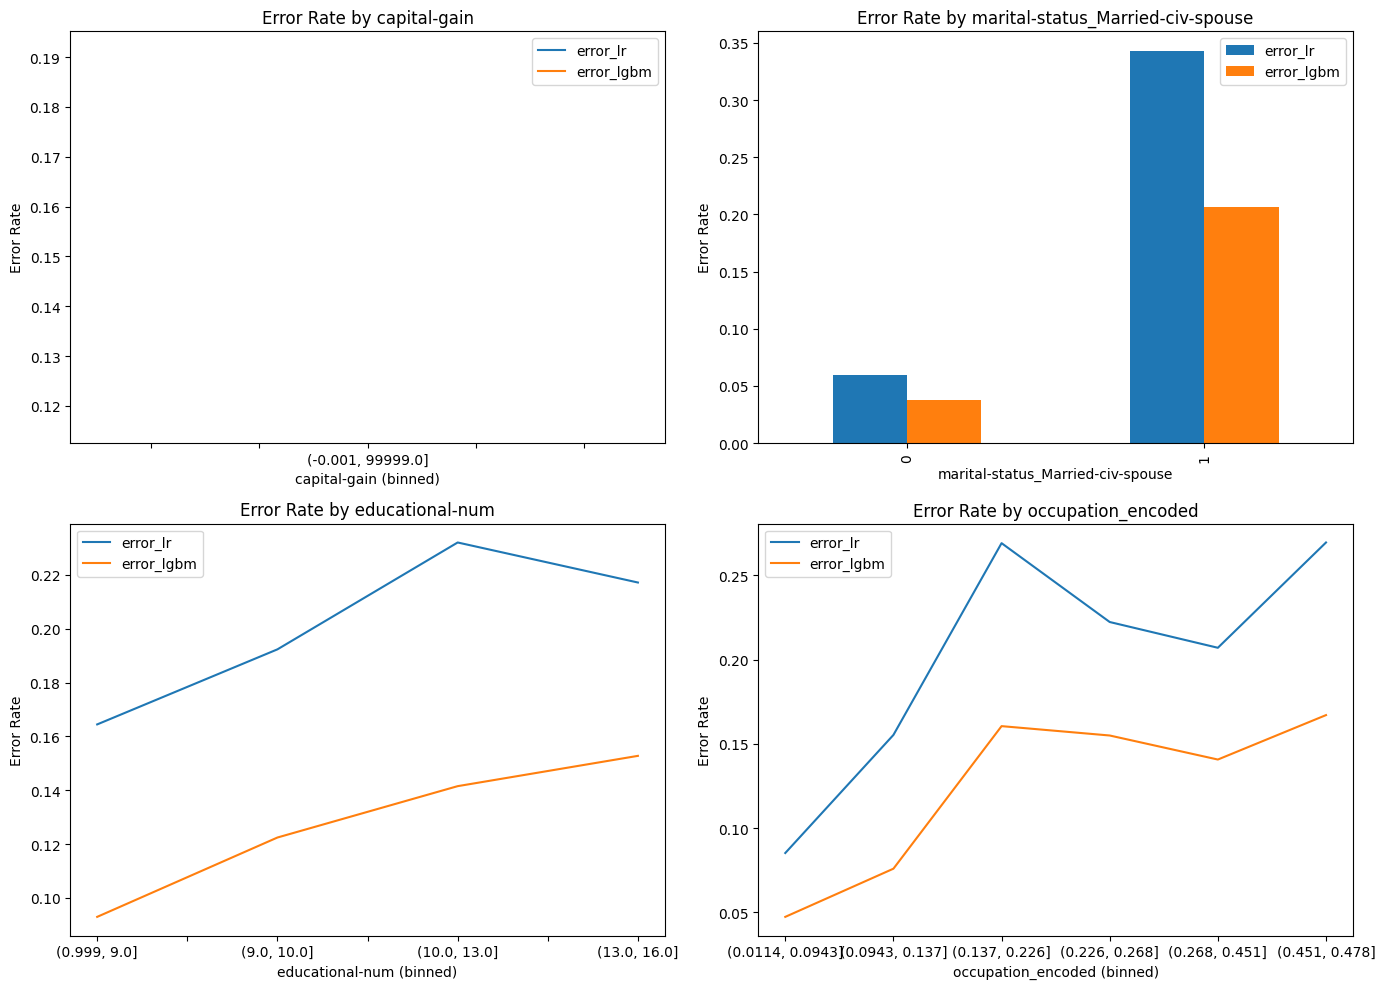

In [19]:
# Error-rate plots for top Logistic Regression features

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import category_encoders as ce

lr_top_features = [
    "capital-gain",
    "marital-status_Married-civ-spouse",
    "educational-num",
    "occupation_encoded",
]

plot_df = X_test.copy()
raw_test = adult.loc[test_idx].copy()
raw_train = adult.loc[train_idx].copy()

# Backfill key plotting columns if current X_test was built from a different feature set
if "occupation_encoded" not in plot_df.columns and "occupation" in raw_test.columns:
    occ_encoder = globals().get("occupation_encoder_full", ce.TargetEncoder(cols=["occupation"]))
    if "occupation_encoder_full" not in globals():
        occ_encoder.fit(raw_train[["occupation"]], raw_train["income"])
    plot_df["occupation_encoded"] = occ_encoder.transform(raw_test[["occupation"]])["occupation"].values

if "marital-status_Married-civ-spouse" not in plot_df.columns and "marital-status" in raw_test.columns:
    plot_df["marital-status_Married-civ-spouse"] = (
        raw_test["marital-status"].astype(str).eq("Married-civ-spouse").astype(int).values
    )

plot_df["error_lr"] = (rf_pred != y_test).astype(int)
plot_df["error_lgbm"] = (xgb_pred != y_test).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, feat in zip(axes, lr_top_features):
    if feat not in plot_df.columns:
        ax.text(0.5, 0.5, f"Missing: {feat}", ha="center", va="center")
        ax.set_title(f"Error Rate by {feat}")
        ax.set_axis_off()
        continue

    s = plot_df[feat]

    if pd.api.types.is_numeric_dtype(s):
        if s.nunique(dropna=True) <= 10:
            grp = plot_df.groupby(feat, observed=False)[["error_lr", "error_lgbm"]].mean()
            grp.plot(kind="bar", ax=ax)
            ax.set_xlabel(feat)
        else:
            binned = pd.qcut(s, q=6, duplicates="drop")
            grp = plot_df.groupby(binned, observed=False)[["error_lr", "error_lgbm"]].mean()
            grp.plot(ax=ax)
            ax.set_xlabel(f"{feat} (binned)")
    else:
        grp = plot_df.groupby(feat, observed=False)[["error_lr", "error_lgbm"]].mean()
        grp.plot(kind="bar", ax=ax)
        ax.set_xlabel(feat)

    ax.set_title(f"Error Rate by {feat}")
    ax.set_ylabel("Error Rate")

plt.tight_layout()
plt.show()

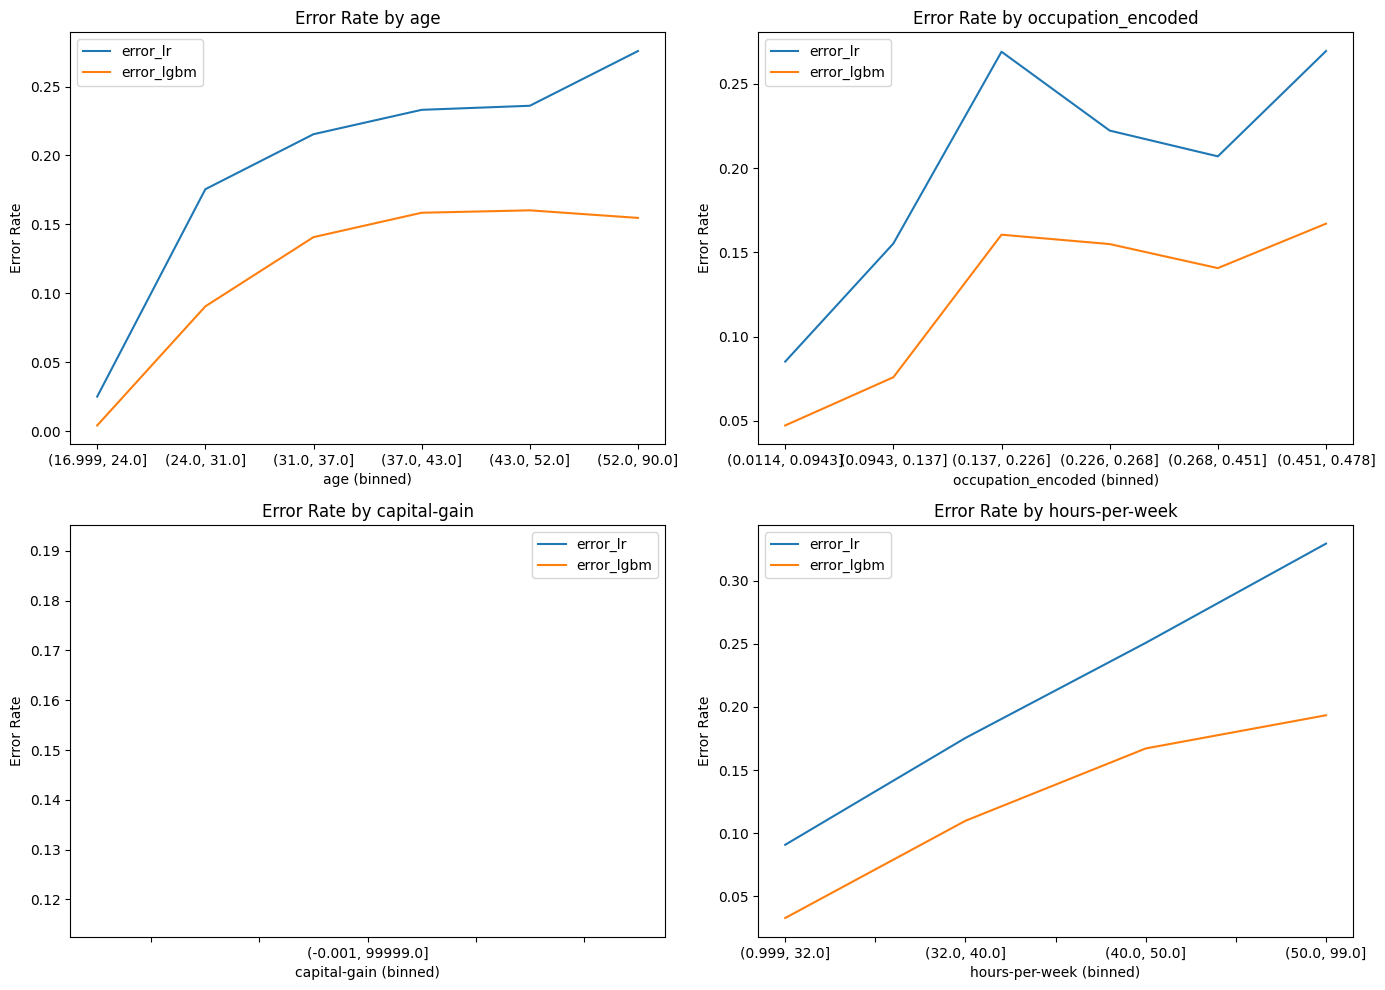

In [20]:
# Error-rate plots for top LightGBM features

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import category_encoders as ce

lgbm_top_features = [
    "age",
    "occupation_encoded",
    "capital-gain",
    "hours-per-week",
]

plot_df = X_test.copy()
raw_test = adult.loc[test_idx].copy()
raw_train = adult.loc[train_idx].copy()

if "occupation_encoded" not in plot_df.columns and "occupation" in raw_test.columns:
    occ_encoder = globals().get("occupation_encoder_full", ce.TargetEncoder(cols=["occupation"]))
    if "occupation_encoder_full" not in globals():
        occ_encoder.fit(raw_train[["occupation"]], raw_train["income"])
    plot_df["occupation_encoded"] = occ_encoder.transform(raw_test[["occupation"]])["occupation"].values

plot_df["error_lr"] = (rf_pred != y_test).astype(int)
plot_df["error_lgbm"] = (xgb_pred != y_test).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, feat in zip(axes, lgbm_top_features):
    if feat not in plot_df.columns:
        ax.text(0.5, 0.5, f"Missing: {feat}", ha="center", va="center")
        ax.set_title(f"Error Rate by {feat}")
        ax.set_axis_off()
        continue

    s = plot_df[feat]

    if pd.api.types.is_numeric_dtype(s):
        if s.nunique(dropna=True) <= 10:
            grp = plot_df.groupby(feat, observed=False)[["error_lr", "error_lgbm"]].mean()
            grp.plot(kind="bar", ax=ax)
            ax.set_xlabel(feat)
        else:
            binned = pd.qcut(s, q=6, duplicates="drop")
            grp = plot_df.groupby(binned, observed=False)[["error_lr", "error_lgbm"]].mean()
            grp.plot(ax=ax)
            ax.set_xlabel(f"{feat} (binned)")
    else:
        grp = plot_df.groupby(feat, observed=False)[["error_lr", "error_lgbm"]].mean()
        grp.plot(kind="bar", ax=ax)
        ax.set_xlabel(feat)

    ax.set_title(f"Error Rate by {feat}")
    ax.set_ylabel("Error Rate")

plt.tight_layout()
plt.show()

In [21]:
# proper OOF target encoding: split first, OOF encode train, encode test from full train
from sklearn.model_selection import KFold

X_base = adult_ohe.drop(columns=["income"]).copy()
y_base = adult_ohe["income"].copy()

X_train_base = X_base.loc[train_idx].copy()
X_test_base = X_base.loc[test_idx].copy()
y_train_base = y_base.loc[train_idx].copy()
y_test_base = y_base.loc[test_idx].copy()

def add_oof_target_encoding(X_train, X_test, y_train, col, new_col, n_splits=5):
    X_train = X_train.copy()
    X_test = X_test.copy()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    X_train[new_col] = np.nan

    for tr_idx, val_idx in kf.split(X_train):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]

        encoder = ce.TargetEncoder(cols=[col])
        encoder.fit(X_tr[[col]], y_tr)

        X_train.iloc[val_idx, X_train.columns.get_loc(new_col)] = (
            encoder.transform(X_val[[col]])[col].values
        )

    final_encoder = ce.TargetEncoder(cols=[col])
    final_encoder.fit(X_train[[col]], y_train)
    X_test[new_col] = final_encoder.transform(X_test[[col]])[col].values

    return X_train, X_test

X_train_oof, X_test_oof = add_oof_target_encoding(
    X_train_base, X_test_base, y_train_base,
    col="occupation", new_col="occupation_oof"
)

X_train_oof, X_test_oof = add_oof_target_encoding(
    X_train_oof, X_test_oof, y_train_base,
    col="native-country", new_col="native_country_oof"
)

X_train_oof.head()

,age,fnlwgt,education,educational-num,occupation,gender,capital-gain,capital-loss,hours-per-week,native-country,...,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,occupation_encoded,native_country_encoded,occupation_oof,native_country_oof
0,25,226802,11th,7,Machine-op-inspct,1,0,0,40,United-States,...,False,True,False,False,False,False,0.126918,0.244248,0.117772,0.244481
1,38,89814,HS-grad,9,Farming-fishing,1,0,0,50,United-States,...,False,True,False,False,False,False,0.116959,0.243781,0.104723,0.243698
5,34,198693,10th,6,Other-service,1,0,0,30,United-States,...,False,True,False,False,False,False,0.040915,0.243781,0.042343,0.244123
6,29,227026,HS-grad,9,NaN,1,0,0,40,United-States,...,False,False,False,False,False,False,0.090343,0.243781,0.096882,0.243698
7,63,104626,Prof-school,15,Prof-specialty,1,3103,0,32,United-States,...,False,False,False,True,False,False,0.452033,0.243781,0.451637,0.245666


In [25]:
# engineering new features based on error analysis insights
X_train_oof["married_occ_interaction"] = (
    X_train_oof["marital-status_Married-civ-spouse"] * X_train_oof["occupation_oof"]
)

X_test_oof["married_occ_interaction"] = (
    X_test_oof["marital-status_Married-civ-spouse"] * X_test_oof["occupation_oof"]
)

# interaction between age and occupation encoding
X_train_oof["age_occ_interaction"] = X_train_oof["age"] * X_train_oof["occupation_oof"]
X_test_oof["age_occ_interaction"] = X_test_oof["age"] * X_test_oof["occupation_oof"]

# income pressure ratio: returns per hour worked
X_train_oof["income_pressure_ratio"] = X_train_oof["capital-gain"] / (X_train_oof["hours-per-week"] + 1)
X_test_oof["income_pressure_ratio"] = X_test_oof["capital-gain"] / (X_test_oof["hours-per-week"] + 1)

# net capital: gain minus loss
X_train_oof["net_capital"] = X_train_oof["capital-gain"] - X_train_oof["capital-loss"]
X_test_oof["net_capital"] = X_test_oof["capital-gain"] - X_test_oof["capital-loss"]

X_train_oof[[
    "marital-status_Married-civ-spouse",
    "occupation_oof",
    "married_occ_interaction",
    "age",
    "age_occ_interaction",
    "income_pressure_ratio",
    "net_capital",
]].head()



,marital-status_Married-civ-spouse,occupation_oof,married_occ_interaction,age,age_occ_interaction,income_pressure_ratio,net_capital
0,False,0.117772,0.000000,25,2.944297,0.000000,0
1,True,0.104723,0.104723,38,3.979466,0.000000,0
5,False,0.042343,0.000000,34,1.439669,0.000000,0
6,False,0.096882,0.000000,29,2.809577,0.000000,0
7,True,0.451637,0.451637,63,28.453137,94.030303,3103


In [26]:
# Logistic Regression + LightGBM with OOF features (balanced accuracy CV)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# build train/test matrices from OOF feature sets
drop_cols = ["occupation", "fnlwgt", "education", "native-country", "occupation_encoded", "native_country_encoded"]

X_train_model = X_train_oof.drop(columns=drop_cols, errors="ignore")
X_test_model = X_test_oof.drop(columns=drop_cols, errors="ignore")
y_train_model = y_train_base
y_test_model = y_test_base

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1) Logistic Regression (scaled, class-weight balanced)
lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, class_weight="balanced", max_iter=2000),
)

lr_cv_scores = cross_val_score(lr, X_train_model, y_train_model, cv=cv, scoring="balanced_accuracy")
print(f"LR CV Balanced Accuracy: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")

lr.fit(X_train_model, y_train_model)
lr_pred = lr.predict(X_test_model)
print("LR Test Accuracy:", accuracy_score(y_test_model, lr_pred))
print("LR Classification Report:\n", classification_report(y_test_model, lr_pred))

# 2) LightGBM (class-weight balanced)
lgbm = LGBMClassifier(random_state=42, class_weight="balanced")

lgbm_cv_scores = cross_val_score(lgbm, X_train_model, y_train_model, cv=cv, scoring="balanced_accuracy")
print(f"LGBM CV Balanced Accuracy: {lgbm_cv_scores.mean():.4f} ± {lgbm_cv_scores.std():.4f}")

lgbm.fit(X_train_model, y_train_model)
lgbm_pred = lgbm.predict(X_test_model)
print("LGBM Test Accuracy:", accuracy_score(y_test_model, lgbm_pred))
print("LGBM Classification Report:\n", classification_report(y_test_model, lgbm_pred))

LR CV Balanced Accuracy: 0.8193 ± 0.0046
LR Test Accuracy: 0.806223769065411
LR Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.80      0.86      7431
           1       0.56      0.84      0.68      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769

[LightGBM] [Info] Number of positive: 7480, number of negative: 23779
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001366 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1385
[LightGBM] [Info] Number of data points in the train set: 31259, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [In

In [ ]:
# Hyperparameter grids for tuning (balanced-accuracy focused)

# Logistic Regression grids
# Use these with GridSearchCV over a pipeline named "lr" (e.g., make_pipeline(StandardScaler(), LogisticRegression(...)))
lr_param_grid = {
        "logisticregression__penalty": ["elasticnet", None],
        "logisticregression__C": [0.01, 0.1, 1.0, 10.0],
        "logisticregression__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
        "logisticregression__solver": ["saga"],
        "logisticregression__class_weight": ["balanced"],
        "logisticregression__max_iter": [3000]
    }

# LightGBM grid
lgbm_param_grid = {
    "n_estimators": [200, 400, 700],
    "learning_rate": [0.02, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth":[-1],
    "min_child_samples": [10, 20, 40],
    "subsample": [0.7, 0.9, 1.0],
    "reg_alpha": [0.0, 0.1, 1.0],
    "reg_lambda": [0.0, 0.1, 1.0, 5.0],
    "class_weight": ["balanced"],
    "random_state": [42],
}


In [27]:
# Optuna tuning: Logistic Regression + LightGBM (using proper OOF target encoding features)
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Use OOF-encoded feature sets
DROP_COLS = ["occupation", "fnlwgt", "education", "native-country", "occupation_encoded", "native_country_encoded"]
X_train_tune = X_train_oof.drop(columns=DROP_COLS, errors="ignore")
X_test_tune = X_test_oof.drop(columns=DROP_COLS, errors="ignore")
y_train_tune = y_train_base
y_test_tune = y_test_base

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# 1) Logistic Regression study
# -----------------------------
def objective_lr(trial):
    penalty_family = trial.suggest_categorical("penalty_family", ["l2", "l1", "elasticnet"])

    if penalty_family == "l2":
        solver = trial.suggest_categorical("solver_l2", ["lbfgs", "newton-cg", "saga"])
        lr_model = LogisticRegression(
            random_state=42,
            class_weight="balanced",
            penalty="l2",
            C=trial.suggest_categorical("C_l2", [0.01, 0.1, 1.0, 10.0, 100.0]),
            solver=solver,
            max_iter=3000,
        )
    elif penalty_family == "l1":
        solver = trial.suggest_categorical("solver_l1", ["liblinear", "saga"])
        lr_model = LogisticRegression(
            random_state=42,
            class_weight="balanced",
            penalty="l1",
            C=trial.suggest_categorical("C_l1", [0.01, 0.1, 1.0, 10.0]),
            solver=solver,
            max_iter=3000,
        )
    else:
        lr_model = LogisticRegression(
            random_state=42,
            class_weight="balanced",
            penalty="elasticnet",
            C=trial.suggest_categorical("C_en", [0.01, 0.1, 1.0, 10.0]),
            l1_ratio=trial.suggest_categorical("l1_ratio", [0.1, 0.3, 0.5, 0.7, 0.9]),
            solver="saga",
            max_iter=4000,
        )

    pipe = make_pipeline(StandardScaler(), lr_model)
    scores = cross_val_score(pipe, X_train_tune, y_train_tune, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
    return scores.mean()

study_lr = optuna.create_study(direction="maximize", study_name="lr_balanced_accuracy")
study_lr.optimize(objective_lr, n_trials=30)

print("Best LR CV Balanced Accuracy:", round(study_lr.best_value, 4))
print("Best LR params:", study_lr.best_params)

# Rebuild and fit best LR
best_lr_params = study_lr.best_params.copy()
family = best_lr_params.pop("penalty_family")

if family == "l2":
    lr_best = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        penalty="l2",
        C=best_lr_params["C_l2"],
        solver=best_lr_params["solver_l2"],
        max_iter=3000,
    )
elif family == "l1":
    lr_best = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        penalty="l1",
        C=best_lr_params["C_l1"],
        solver=best_lr_params["solver_l1"],
        max_iter=3000,
    )
else:
    lr_best = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        penalty="elasticnet",
        C=best_lr_params["C_en"],
        l1_ratio=best_lr_params["l1_ratio"],
        solver="saga",
        max_iter=4000,
    )

lr_best_pipe = make_pipeline(StandardScaler(), lr_best)
lr_best_pipe.fit(X_train_tune, y_train_tune)
lr_best_pred = lr_best_pipe.predict(X_test_tune)

print("\nLR Test Accuracy:", accuracy_score(y_test_tune, lr_best_pred))
print("LR Classification Report:\n", classification_report(y_test_tune, lr_best_pred))

# --------------------
# 2) LightGBM study
# --------------------
def objective_lgbm(trial):
    params = {
        "random_state": 42,
        "class_weight": "balanced",
        "n_estimators": trial.suggest_categorical("n_estimators", [200, 400, 700]),
        "learning_rate": trial.suggest_categorical("learning_rate", [0.02, 0.05, 0.1]),
        "num_leaves": trial.suggest_categorical("num_leaves", [15, 31, 63]),
        "max_depth": trial.suggest_categorical("max_depth", [-1, 6, 10]),
        "min_child_samples": trial.suggest_categorical("min_child_samples", [10, 20, 40]),
        "subsample": trial.suggest_categorical("subsample", [0.7, 0.9, 1.0]),
        "colsample_bytree": trial.suggest_categorical("colsample_bytree", [0.7, 0.9, 1.0]),
        "reg_alpha": trial.suggest_categorical("reg_alpha", [0.0, 0.1, 1.0]),
        "reg_lambda": trial.suggest_categorical("reg_lambda", [0.0, 0.1, 1.0, 5.0]),
        "verbosity": -1,
    }

    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_tune, y_train_tune, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
    return scores.mean()

study_lgbm = optuna.create_study(direction="maximize", study_name="lgbm_balanced_accuracy")
study_lgbm.optimize(objective_lgbm, n_trials=30)

print("\nBest LGBM CV Balanced Accuracy:", round(study_lgbm.best_value, 4))
print("Best LGBM params:", study_lgbm.best_params)

lgbm_best_params = study_lgbm.best_params.copy()
lgbm_best_params.update({"random_state": 42, "class_weight": "balanced", "verbosity": -1})
lgbm_best = LGBMClassifier(**lgbm_best_params)
lgbm_best.fit(X_train_tune, y_train_tune)
lgbm_best_pred = lgbm_best.predict(X_test_tune)

print("\nLGBM Test Accuracy:", accuracy_score(y_test_tune, lgbm_best_pred))
print("LGBM Classification Report:\n", classification_report(y_test_tune, lgbm_best_pred))

[I 2026-04-22 13:44:06,736] A new study created in memory with name: lr_balanced_accuracy
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versi

Best LR CV Balanced Accuracy: 0.8199
Best LR params: {'penalty_family': 'l2', 'solver_l2': 'saga', 'C_l2': 0.01}


[I 2026-04-22 13:46:18,549] A new study created in memory with name: lgbm_balanced_accuracy



LR Test Accuracy: 0.8079639676527792
LR Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.80      0.86      7431
           1       0.57      0.84      0.68      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769



[I 2026-04-22 13:46:25,502] Trial 0 finished with value: 0.8399648524960062 and parameters: {'n_estimators': 700, 'learning_rate': 0.1, 'num_leaves': 15, 'max_depth': 10, 'min_child_samples': 40, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 5.0}. Best is trial 0 with value: 0.8399648524960062.
[I 2026-04-22 13:46:29,057] Trial 1 finished with value: 0.845563965760854 and parameters: {'n_estimators': 200, 'learning_rate': 0.1, 'num_leaves': 63, 'max_depth': 6, 'min_child_samples': 20, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 1.0}. Best is trial 1 with value: 0.845563965760854.
[I 2026-04-22 13:46:38,476] Trial 2 finished with value: 0.8439270750509278 and parameters: {'n_estimators': 700, 'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': 6, 'min_child_samples': 40, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 5.0}. Best is trial 1 with value: 0.845563965760854.
[I 2026-04-22 13:46:41,862] T


Best LGBM CV Balanced Accuracy: 0.8456
Best LGBM params: {'n_estimators': 200, 'learning_rate': 0.1, 'num_leaves': 63, 'max_depth': 6, 'min_child_samples': 20, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 1.0}

LGBM Test Accuracy: 0.8428703040229297
LGBM Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.83      0.89      7431
           1       0.62      0.88      0.73      2338

    accuracy                           0.84      9769
   macro avg       0.79      0.86      0.81      9769
weighted avg       0.88      0.84      0.85      9769



In [29]:
# Weighted probability ensemble (LR + LightGBM) with Optuna-optimized blend weight
from sklearn.base import clone
from sklearn.metrics import balanced_accuracy_score

# Reuse tuned matrices if available; otherwise rebuild from OOF sets
if "X_train_tune" not in globals():
    DROP_COLS = ["occupation", "fnlwgt", "education", "native-country", "occupation_encoded", "native_country_encoded"]
    X_train_tune = X_train_oof.drop(columns=DROP_COLS, errors="ignore")
    X_test_tune = X_test_oof.drop(columns=DROP_COLS, errors="ignore")
    y_train_tune = y_train_base
    y_test_tune = y_test_base

# Build best tuned models from Optuna studies when available
if "lr_best_pipe" in globals():
    lr_blend_model = clone(lr_best_pipe)
elif "study_lr" in globals():
    # LR tuning is elastic-net only
    lr_params = study_lr.best_params.copy()
    best_c = lr_params.get("C_en", lr_params.get("C", 1.0))
    best_l1_ratio = lr_params.get("l1_ratio", 0.5)

    lr_best = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        penalty="elasticnet",
        C=best_c,
        l1_ratio=best_l1_ratio,
        solver="saga",
        max_iter=4000,
    )

    lr_blend_model = make_pipeline(StandardScaler(), lr_best)
else:
    lr_blend_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            random_state=42,
            class_weight="balanced",
            penalty="elasticnet",
            l1_ratio=0.5,
            solver="saga",
            max_iter=4000,
        )
    )

if "lgbm_best" in globals():
    lgbm_blend_model = clone(lgbm_best)
elif "study_lgbm" in globals():
    lgbm_params = study_lgbm.best_params.copy()
    lgbm_params.update({"random_state": 42, "class_weight": "balanced", "verbosity": -1})
    lgbm_blend_model = LGBMClassifier(**lgbm_params)
else:
    lgbm_blend_model = LGBMClassifier(random_state=42, class_weight="balanced", verbosity=-1)

blend_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_blend(trial):
    w_lr = trial.suggest_float("w_lr", 0.0, 1.0)

    oof_blend_proba = np.zeros(len(X_train_tune))

    for tr_idx, val_idx in blend_cv.split(X_train_tune, y_train_tune):
        X_tr, X_val = X_train_tune.iloc[tr_idx], X_train_tune.iloc[val_idx]
        y_tr, y_val = y_train_tune.iloc[tr_idx], y_train_tune.iloc[val_idx]

        lr_fold = clone(lr_blend_model)
        lgbm_fold = clone(lgbm_blend_model)

        lr_fold.fit(X_tr, y_tr)
        lgbm_fold.fit(X_tr, y_tr)

        p_lr = lr_fold.predict_proba(X_val)[:, 1]
        p_lgbm = lgbm_fold.predict_proba(X_val)[:, 1]

        p_blend = w_lr * p_lr + (1.0 - w_lr) * p_lgbm
        oof_blend_proba[val_idx] = p_blend

    y_pred = (oof_blend_proba >= 0.5).astype(int)
    return balanced_accuracy_score(y_train_tune, y_pred)

study_blend = optuna.create_study(direction="maximize", study_name="lr_lgbm_probability_blend")
study_blend.optimize(objective_blend, n_trials=30)

best_w_lr = study_blend.best_params["w_lr"]
best_w_lgbm = 1.0 - best_w_lr

print(f"Best blend CV Balanced Accuracy: {study_blend.best_value:.4f}")
print(f"Best weights -> LR: {best_w_lr:.4f}, LGBM: {best_w_lgbm:.4f}")

# Fit base models on full train and evaluate blended predictions on test
lr_blend_model.fit(X_train_tune, y_train_tune)
lgbm_blend_model.fit(X_train_tune, y_train_tune)

p_lr_test = lr_blend_model.predict_proba(X_test_tune)[:, 1]
p_lgbm_test = lgbm_blend_model.predict_proba(X_test_tune)[:, 1]
p_blend_test = best_w_lr * p_lr_test + best_w_lgbm * p_lgbm_test

blend_pred = (p_blend_test >= 0.5).astype(int)

print("Blended Test Accuracy:", accuracy_score(y_test_tune, blend_pred))
print("Blended Classification Report:\n", classification_report(y_test_tune, blend_pred))

[I 2026-04-22 13:56:41,160] A new study created in memory with name: lr_lgbm_probability_blend
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/

Best blend CV Balanced Accuracy: 0.8459
Best weights -> LR: 0.2966, LGBM: 0.7034
Blended Test Accuracy: 0.8406182823216296
Blended Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.83      0.89      7431
           1       0.62      0.88      0.73      2338

    accuracy                           0.84      9769
   macro avg       0.79      0.85      0.81      9769
weighted avg       0.88      0.84      0.85      9769



### Model Evaluation Summary

The most consistently useful features were `capital-gain`, `educational-num`, marital-status indicators (especially married), and occupation target-encoding features (`occupation_oof` / `occupation_encoded`). The engineered interaction feature like age-occupation interaction and net-capital were supposed to help capture nonlinear behavior that one-hot features missed.
LightGBM outperformed Logistic Regression on test accuracy and generally captured more signal from mixed numeric/categorical interactions.
Logistic Regression is interpretable, but it just didnt perform as well
The probability ensemble gave a slightly better CV balanced accuracy, but the accuracy did not pass the best LightGBM result by itself by much.
The optimized blend weight favored LightGBM, which makes sense because it almost always performed the best
Its important to always keep in mind a leakage-safe workflow: split first, OOF encode train, transform test from train-fitted encoders, then tune models with balanced-accuracy CV.


In [30]:
# Compare balanced accuracy across baseline, tuned, and ensemble models
from sklearn.metrics import balanced_accuracy_score

results = []

def add_test_result(name, y_var_name, pred_var_name):
    if y_var_name in globals() and pred_var_name in globals():
        y_true_local = globals()[y_var_name]
        y_pred_local = globals()[pred_var_name]
        if len(y_true_local) == len(y_pred_local):
            results.append({
                "model": name,
                "split": "test",
                "balanced_accuracy": balanced_accuracy_score(y_true_local, y_pred_local),
            })

# Baseline models (earlier section)
add_test_result("Baseline LogisticRegression", "y_test", "rf_pred")
add_test_result("Baseline LightGBM", "y_test", "xgb_pred")

# OOF feature models (non-tuned)
add_test_result("OOF LogisticRegression", "y_test_model", "lr_pred")
add_test_result("OOF LightGBM", "y_test_model", "lgbm_pred")

# Tuned models
add_test_result("Tuned LogisticRegression (Optuna)", "y_test_tune", "lr_best_pred")
add_test_result("Tuned LightGBM (Optuna)", "y_test_tune", "lgbm_best_pred")

# Ensemble model
add_test_result("Weighted Ensemble (LR+LGBM, Optuna)", "y_test_tune", "blend_pred")

# Add CV balanced-accuracy summaries when available
if "study_lr" in globals():
    results.append({
        "model": "Tuned LogisticRegression (Optuna)",
        "split": "cv_best",
        "balanced_accuracy": float(study_lr.best_value),
    })

if "study_lgbm" in globals():
    results.append({
        "model": "Tuned LightGBM (Optuna)",
        "split": "cv_best",
        "balanced_accuracy": float(study_lgbm.best_value),
    })

if "study_blend" in globals():
    results.append({
        "model": "Weighted Ensemble (LR+LGBM, Optuna)",
        "split": "cv_best",
        "balanced_accuracy": float(study_blend.best_value),
    })

if results:
    results_df = pd.DataFrame(results).sort_values(["split", "balanced_accuracy"], ascending=[True, False])
    results_df["balanced_accuracy"] = results_df["balanced_accuracy"].round(4)
    display(results_df)
else:
    print("No model predictions/studies found in memory. Re-run the modeling cells first.")

,model,split,balanced_accuracy
9,"Weighted Ensemble (LR+LGBM, Optuna)",cv_best,0.8459
8,Tuned LightGBM (Optuna),cv_best,0.8456
7,Tuned LogisticRegression (Optuna),cv_best,0.8199
3,OOF LightGBM,test,0.8564
5,Tuned LightGBM (Optuna),test,0.8560
6,"Weighted Ensemble (LR+LGBM, Optuna)",test,0.8543
4,Tuned LogisticRegression (Optuna),test,0.8190
2,OOF LogisticRegression,test,0.8184
0,Baseline LogisticRegression,test,0.8183
1,Baseline LightGBM,test,0.8085
